### Try to use halving search instead of optuna to have faster results

In [ ]:
! pip install lightgbm

In [ ]:
! pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 24.7 MB/s eta 0:00:00


In [ ]:
! pip install optuna.integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 9.0 MB/s eta 0:00:00


In [ ]:
!pip install -U xgboost optuna


In [ ]:
!pip install scikeras

In [ ]:
! pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [47]:
#LIBRARY
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib as mpl
# AdaBoost Algorithm
from sklearn.ensemble import AdaBoostClassifier
# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# XGBoost
import xgboost
from xgboost import XGBClassifier
from xgboost import plot_importance, to_graphviz, plot_tree
print("XGBoost version:",xgboost.__version__)
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
import math
from keras.models import Sequential
from keras.layers import Dense, Dropout, BatchNormalization, GaussianNoise, LSTM, RepeatVector, TimeDistributed, Input,Bidirectional
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 13
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import tensorflow.random as tf_r
import tensorflow as tf
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from sklearn.preprocessing import StandardScaler
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from scikeras.wrappers import KerasRegressor
import os
import requests
import io
import zipfile
import seaborn as sns
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
# Model imports
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import matplotlib.patches as mpatches
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix


XGBoost version: 3.2.0


In [ ]:
def load_har_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    def load_group(group, base_path="UCI HAR Dataset/"):
        path = base_path + group + "/Inertial Signals/"
        filenames = [
            'body_acc_x_', 'body_acc_y_', 'body_acc_z_',
            'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',
            'total_acc_x_', 'total_acc_y_', 'total_acc_z_'
        ]

        signals = []
        for name in filenames:
            file_path = path + name + group + ".txt"
            df = pd.read_csv(z.open(file_path), header=None, sep='\s+')
            signals.append(df.values)

        return np.transpose(np.array(signals), (1, 2, 0))

    X_train_full = load_group("train")
    X_test = load_group("test")

    y_train = pd.read_csv(z.open("UCI HAR Dataset/train/y_train.txt"), header=None, sep='\s+').values
    y_test = pd.read_csv(z.open("UCI HAR Dataset/test/y_test.txt"), header=None, sep='\s+').values

    y_train_full = to_categorical(y_train - 1)
    y_test_cat = to_categorical(y_test - 1)

    return X_train_full, y_train_full, X_test, y_test_cat


X_train_full, y_train_cat_full, X_test, y_test_cat = load_har_dataset()

input_shape = (X_train_full.shape[1], X_train_full.shape[2]) # (128, 9)
num_classes = y_train_cat_full.shape[1]


<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
<>:17: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:26: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2629/3928300800.py:17: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(z.open(file_path), header=None, sep='\s+')
/tmp/ipykernel_2629/3928300800.py:25: SyntaxWarning: invalid escape sequence '\s'
  y_train = pd.read_csv(z.open("UCI HAR Dataset/train/y_train.txt"), header=None, sep='\s+').values
/tmp/ipykernel_2629/3928300800.py:26: SyntaxWarning: invalid escape sequence '\s'
  y_test = pd.read_csv(z.open("UCI HAR Dataset/test/y_test.txt"), header=None, sep='\s+').values


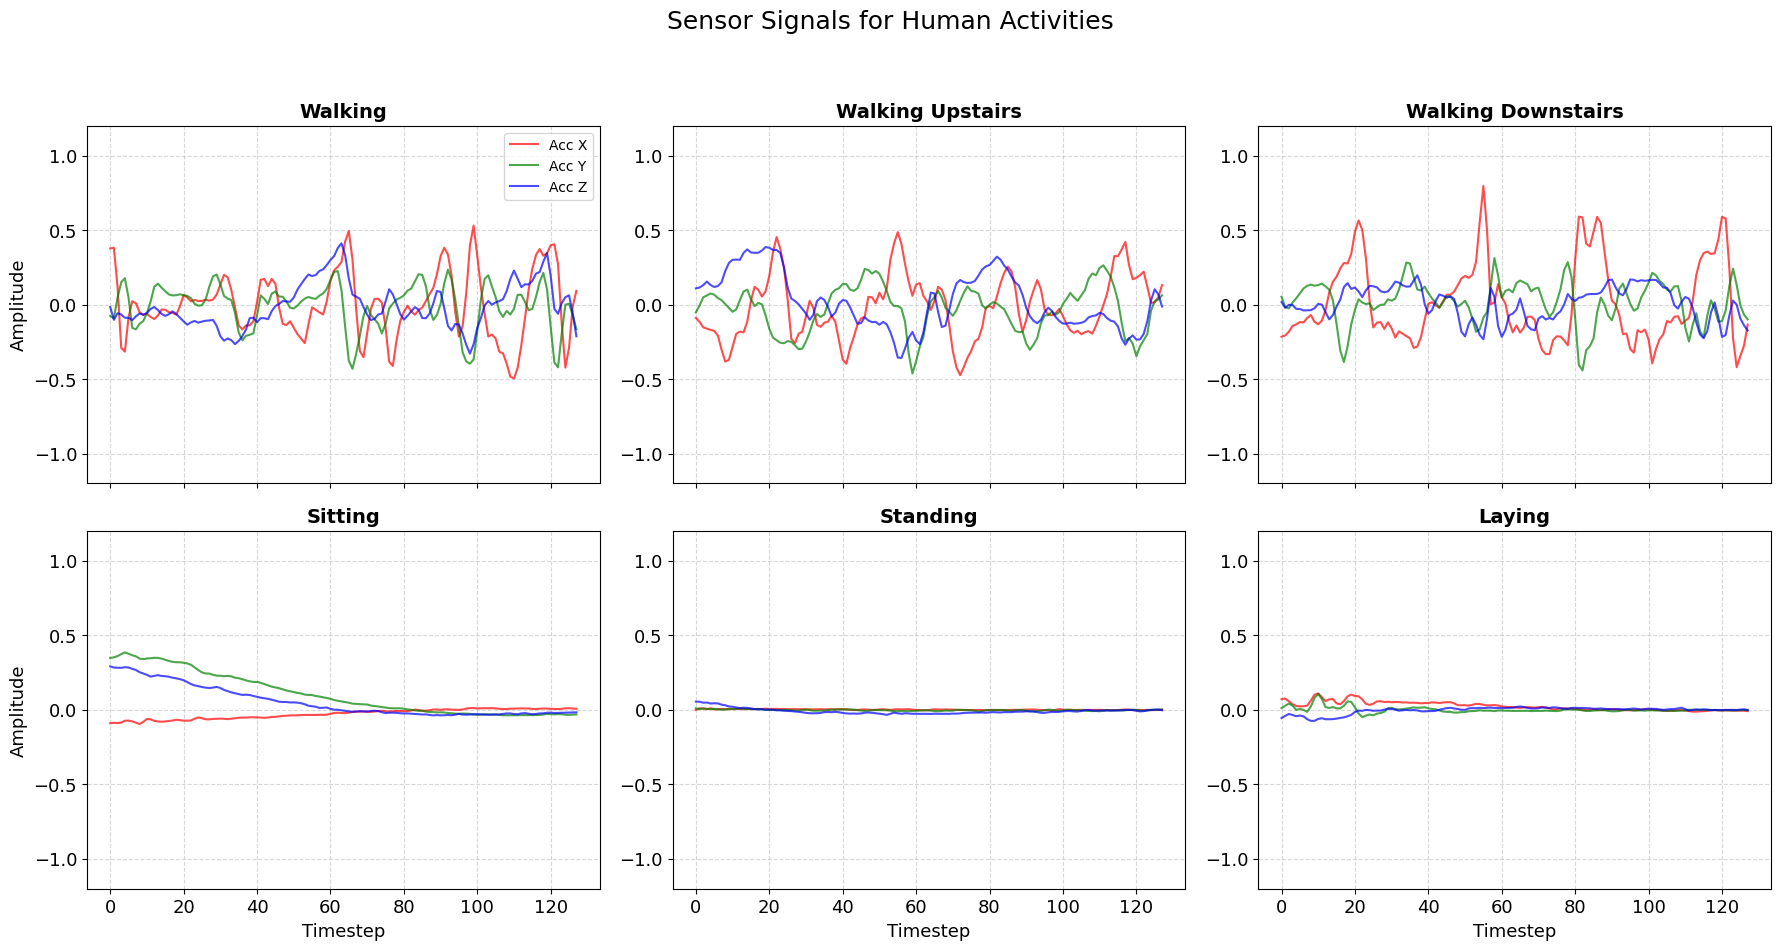

In [ ]:
def plot_activity_grid(X, y_cat, labels):
    y_int = np.argmax(y_cat, axis=1)
    unique_activities = np.unique(y_int)

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
    fig.suptitle('Sensor Signals for Human Activities', fontsize=18)
    axes = axes.flatten()

    for i, activity_idx in enumerate(unique_activities):
        sample_idx = np.where(y_int == activity_idx)[0][0]
        sample_data = X[sample_idx]

        axes[i].plot(sample_data[:, 0], label='Acc X', color='red', alpha=0.7)
        axes[i].plot(sample_data[:, 1], label='Acc Y', color='green', alpha=0.7)
        axes[i].plot(sample_data[:, 2], label='Acc Z', color='blue', alpha=0.7)

        axes[i].set_title(labels[activity_idx], fontsize=14, fontweight='bold')
        axes[i].set_ylim(-1.2, 1.2)
        axes[i].grid(True, linestyle='--', alpha=0.5)

        if i == 0:
            axes[i].legend(loc='upper right', fontsize=10)

        if i >= 3:
            axes[i].set_xlabel('Timestep')
        if i % 3 == 0:
            axes[i].set_ylabel('Amplitude')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

activity_labels = ['Walking', 'Walking Upstairs', 'Walking Downstairs', 'Sitting', 'Standing', 'Laying']
plot_activity_grid(X_train_full, y_train_cat_full, activity_labels)

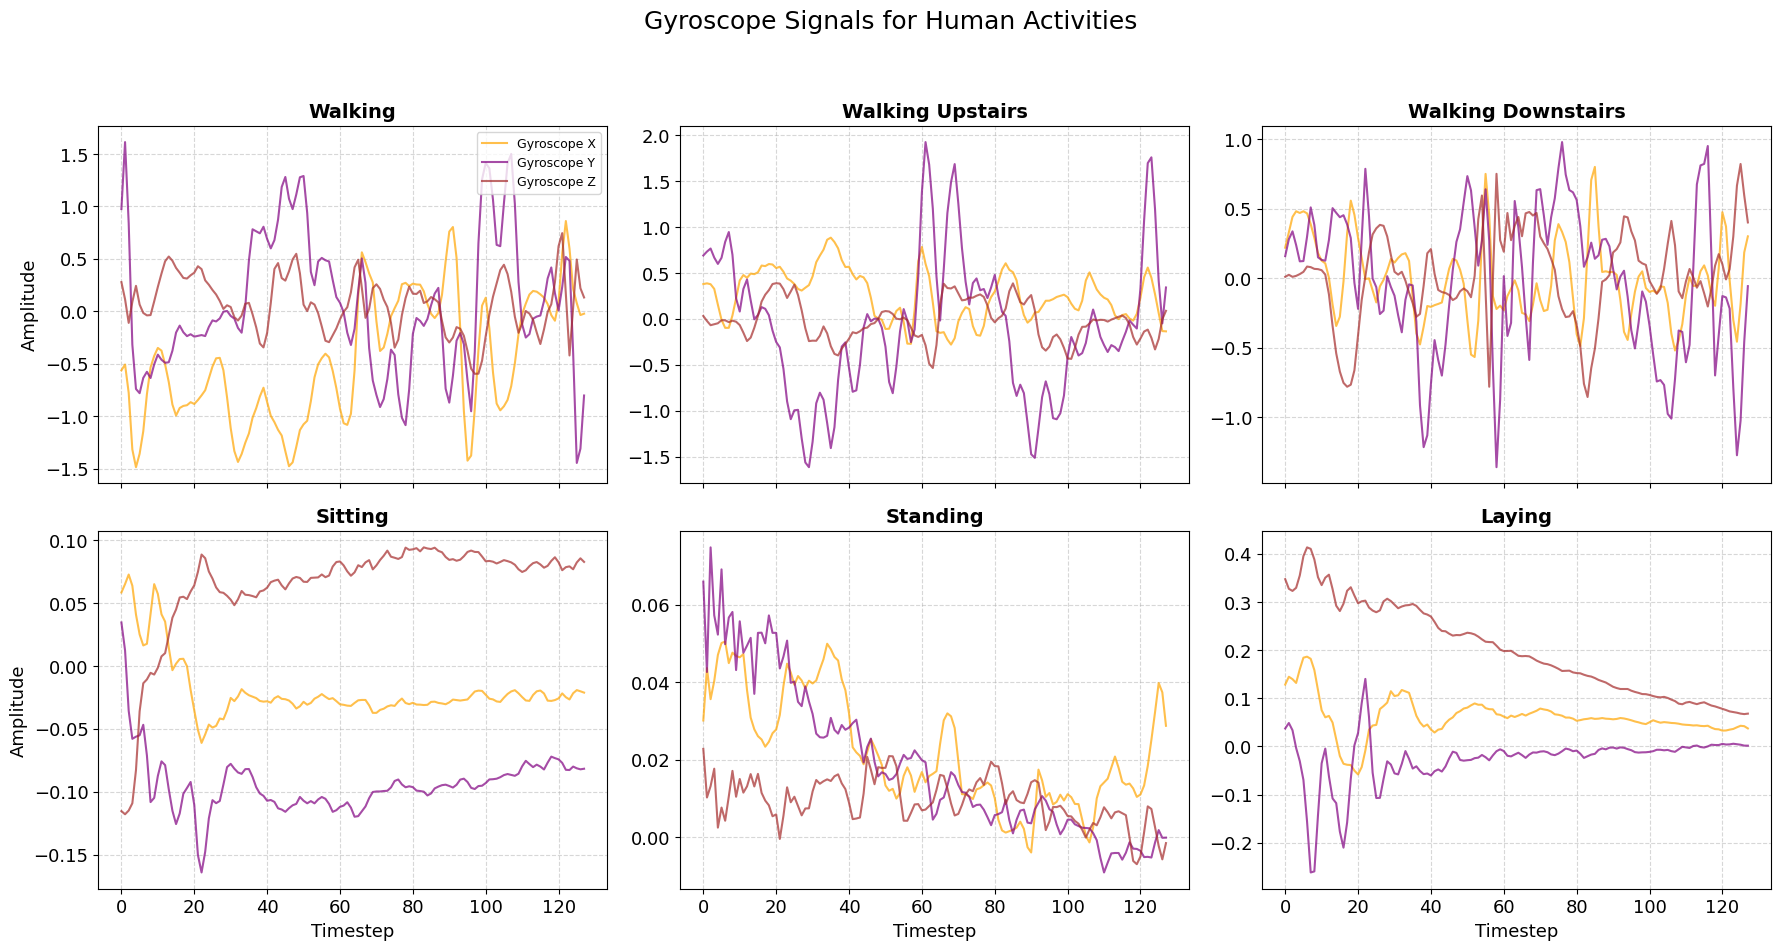

In [ ]:
def plot_activity_grid_advanced(X, y_cat, labels, feature_type='Gyroscope'):
    y_int = np.argmax(y_cat, axis=1)
    unique_activities = np.unique(y_int)

    # Mapping feature types to column indices
    # 0-2: Body Acc, 3-5: Gyro, 6-8: Total Acc
    start_idx = 3 if feature_type == 'Gyroscope' else 6
    colors = ['orange', 'purple', 'brown'] if feature_type == 'Gyroscope' else ['cyan', 'magenta', 'olive']
    axis_labels = ['X', 'Y', 'Z']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
    fig.suptitle(f'{feature_type} Signals for Human Activities', fontsize=18)
    axes = axes.flatten()

    for i, activity_idx in enumerate(unique_activities):
        sample_idx = np.where(y_int == activity_idx)[0][0]
        sample_data = X[sample_idx]

        for j in range(3):
            axes[i].plot(sample_data[:, start_idx + j],
                         label=f'{feature_type} {axis_labels[j]}',
                         color=colors[j], alpha=0.7)

        axes[i].set_title(labels[activity_idx], fontsize=14, fontweight='bold')
        axes[i].grid(True, linestyle='--', alpha=0.5)

        if i == 0:
            axes[i].legend(loc='upper right', fontsize=9)

        if i >= 3:
            axes[i].set_xlabel('Timestep')
        if i % 3 == 0:
            axes[i].set_ylabel('Amplitude')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# To plot Gyroscope data
plot_activity_grid_advanced(X_train_full, y_train_cat_full, activity_labels, feature_type='Gyroscope')


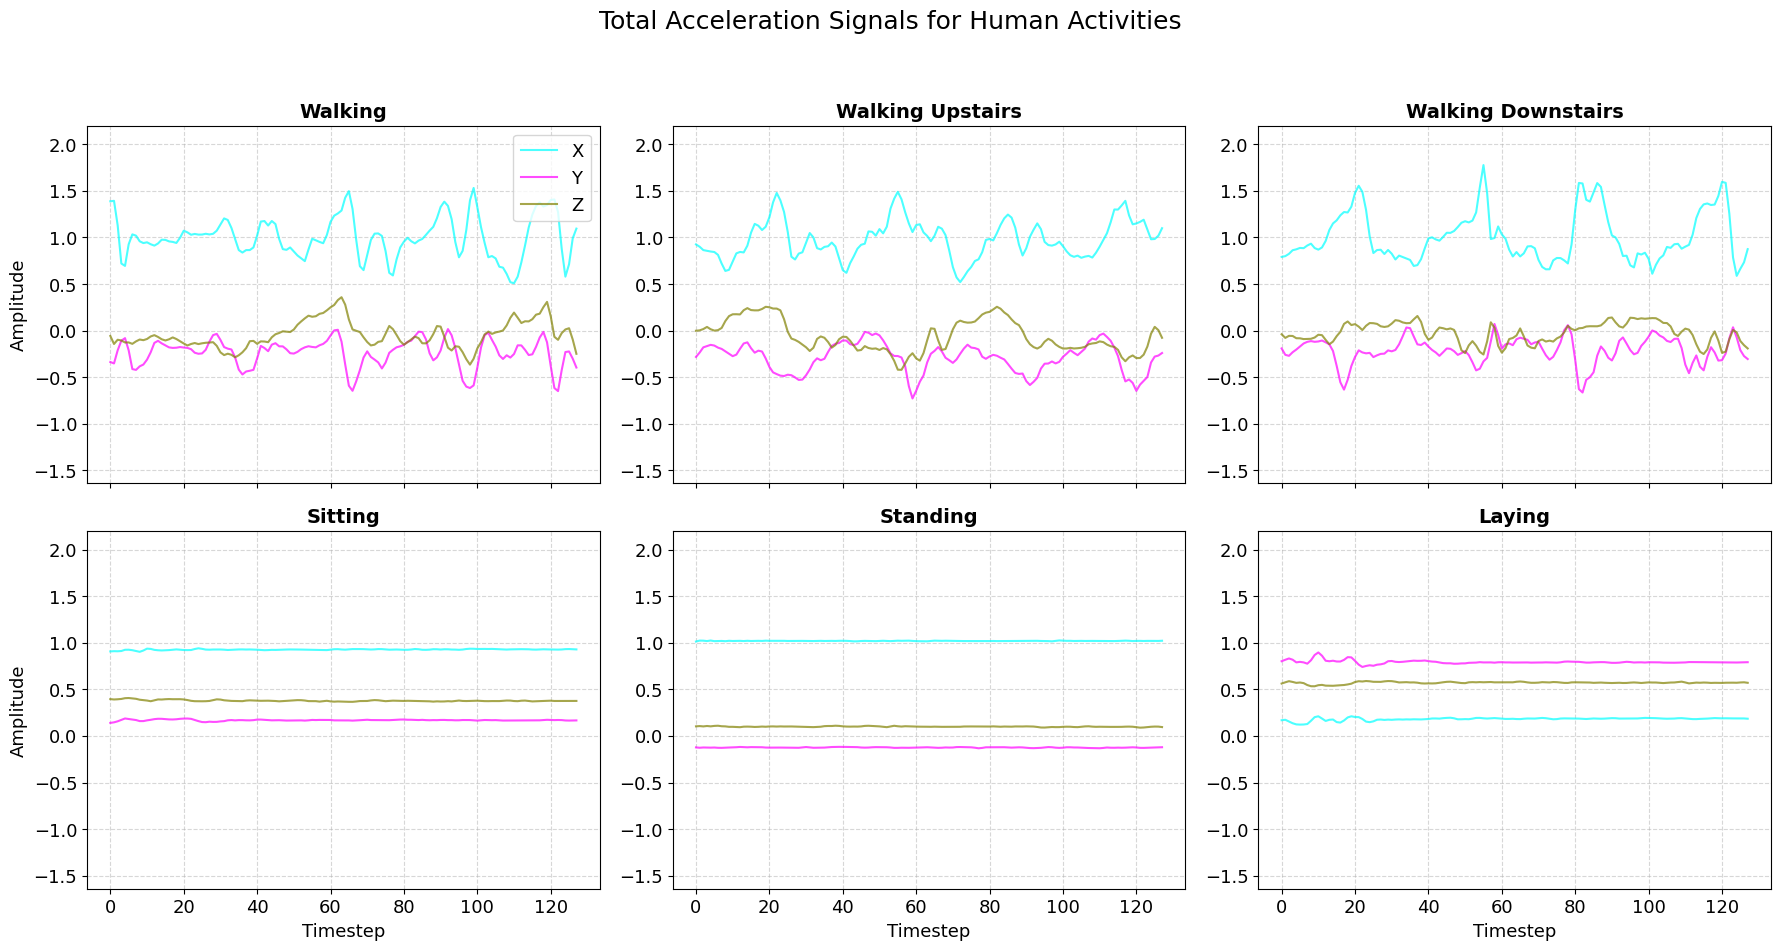

In [ ]:
def plot_activity_grid_all_features(X, y_cat, labels, mode='total'):
    y_int = np.argmax(y_cat, axis=1)
    unique_activities = np.unique(y_int)

    # 0-2: Body Acc | 3-5: Gyro | 6-8: Total Acc
    if mode == 'body':
        start_idx = 0
        title_prefix = 'Body Acceleration'
        colors = ['red', 'green', 'blue']
    elif mode == 'gyro':
        start_idx = 3
        title_prefix = 'Gyroscope'
        colors = ['orange', 'purple', 'brown']
    else:
        start_idx = 6
        title_prefix = 'Total Acceleration'
        colors = ['cyan', 'magenta', 'olive']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)
    fig.suptitle(f'{title_prefix} Signals for Human Activities', fontsize=18)
    axes = axes.flatten()

    for i, activity_idx in enumerate(unique_activities):
        sample_idx = np.where(y_int == activity_idx)[0][0]
        sample_data = X[sample_idx]

        axes[i].plot(sample_data[:, start_idx], label='X', color=colors[0], alpha=0.7)
        axes[i].plot(sample_data[:, start_idx + 1], label='Y', color=colors[1], alpha=0.7)
        axes[i].plot(sample_data[:, start_idx + 2], label='Z', color=colors[2], alpha=0.7)

        axes[i].set_title(labels[activity_idx], fontsize=14, fontweight='bold')
        axes[i].set_ylim(X[:,:,start_idx:start_idx+3].min(), X[:,:,start_idx:start_idx+3].max())
        axes[i].grid(True, linestyle='--', alpha=0.5)

        if i == 0:
            axes[i].legend(loc='upper right')
        if i >= 3:
            axes[i].set_xlabel('Timestep')
        if i % 3 == 0:
            axes[i].set_ylabel('Amplitude')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Plotting Total Acceleration
plot_activity_grid_all_features(X_train_full, y_train_cat_full, activity_labels, mode='total')



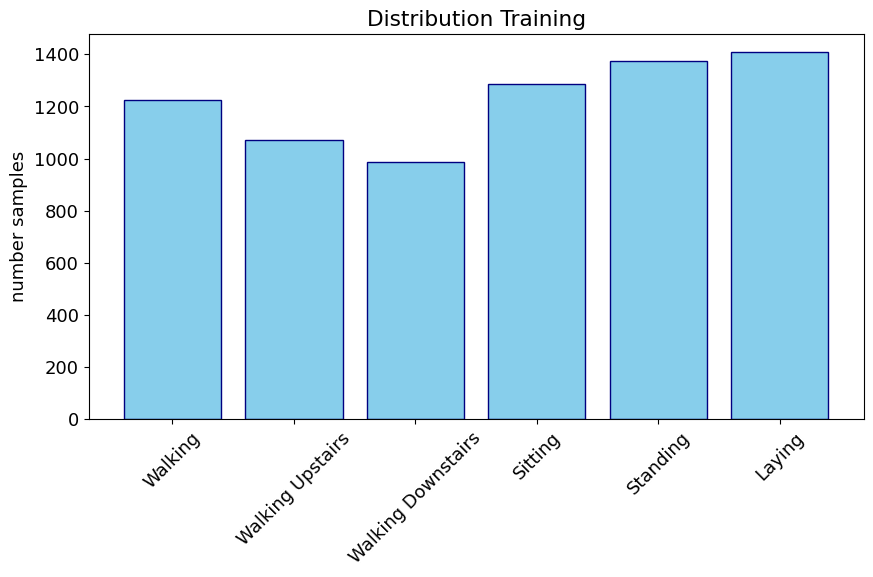

In [ ]:
def plot_class_distribution(y_cat, labels):
    y_int = np.argmax(y_cat, axis=1)
    counts = np.bincount(y_int)

    plt.figure(figsize=(10, 5))
    plt.bar(labels, counts, color='skyblue', edgecolor='navy')
    plt.title('Distribution Training')
    plt.ylabel('number samples')
    plt.xticks(rotation=45)
    plt.show()

plot_class_distribution(y_train_cat_full, activity_labels)

In [48]:
performance_registry = []
confusion_matrices_registry = {}

def register_model_metrics(pipeline_name, model_name, y_true, y_pred):
    report_dict = classification_report(y_true, y_pred, target_names=activity_labels, output_dict=True)
    acc = accuracy_score(y_true, y_pred)
    performance_registry.append({
        "Pipeline": pipeline_name,
        "Model": model_name,
        "Accuracy": acc,
        "Macro_Precision": report_dict["macro avg"]["precision"],
        "Macro_Recall": report_dict["macro avg"]["recall"],
        "Macro_F1": report_dict["macro avg"]["f1-score"]
    })
    confusion_matrices_registry[f"{pipeline_name} - {model_name}"] = (confusion_matrix(y_true, y_pred), acc)

<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:23: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2629/3046196043.py:15: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(z.open(file_path), header=None, sep='\s+')
/tmp/ipykernel_2629/3046196043.py:22: SyntaxWarning: invalid escape sequence '\s'
  y_train = pd.read_csv(z.open("UCI HAR Dataset/train/y_train.txt"), header=None, sep='\s+').values.ravel() - 1
/tmp/ipykernel_2629/3046196043.py:23: SyntaxWarning: invalid escape sequence '\s'
  y_test = pd.read_csv(z.open("UCI HAR Dataset/test/y_test.txt"), header=None, sep='\s+').values.ravel() - 1


New Feature Count: 1152 (Raw signals flattened)


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=204. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.1}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=204. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'num_leaves': 63, 'n_estimators': 100, 'learning_rate': 0.2}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=204. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Params: {'learning_rate': 0.1, 'iterations': 200, 'depth': 6}
PERFORMANCE REPORT: XGBoost
                    precision    recall  f1-score   support

           WALKING       0.86      0.98      0.92       496
  WALKING_UPSTAIRS       0.92      0.82      0.87       471
WALKING_DOWNSTAIRS       0.93      0.94      0.93       420
           SITTING       0.87      0.83      0.85       491
          STANDING       0.87      0.88      0.87       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


PERFORMANCE REPORT: LightGBM
                    precision    recall  f1-score   support

           WALKING       0.92      0.96      0.94       496
  WALKING_UPSTAIRS       0.93      0.89      0.91       471
WALKING_DOWNSTAIRS       0.91      0.95      0.93       420
           SITTING       0.83      0.80      0.81       491
          STANDING       0.85      0.84      0.85       532
            LAYING       1.00      1.00      1.00       537

          accuracy                           0.91      2947
         macro avg       0.91      0.91      0.91      2947
      weighted avg       0.91      0.91      0.91      2947

PERFORMANCE REPORT: CatBoost
                    precision    recall  f1-score   support

           WALKING       0.92      0.93      0.92       496
  WALKING_UPSTAIRS       0.90      0.86      0.88       471
WALKING_DOWNSTAIRS       0.87      0.92      0.89       420
           SITTING       0.82      0.81      0.82       491
          STANDING       0.83      0.8

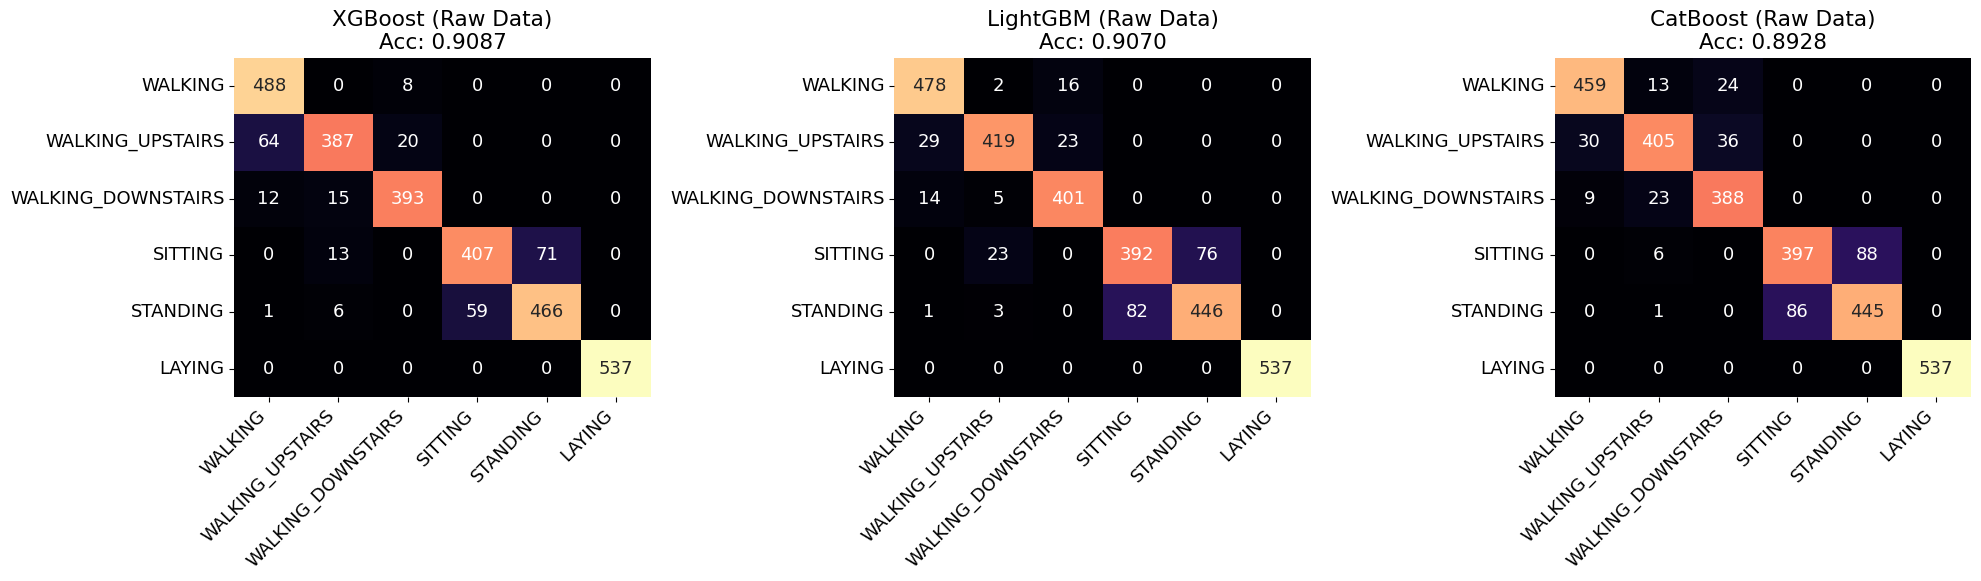

In [59]:

# Data loading
def load_har_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    def load_group(group):
        path = f"UCI HAR Dataset/{group}/Inertial Signals/"
        filenames = ['body_acc_x_', 'body_acc_y_', 'body_acc_z_',
                     'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',
                     'total_acc_x_', 'total_acc_y_', 'total_acc_z_']
        signals = []
        for name in filenames:
            file_path = f"{path}{name}{group}.txt"
            df = pd.read_csv(z.open(file_path), header=None, sep='\s+')
            signals.append(df.values)
        # Returns (samples, 128, 9)
        return np.transpose(np.array(signals), (1, 2, 0))

    X_train_raw = load_group("train")
    X_test_raw = load_group("test")
    y_train = pd.read_csv(z.open("UCI HAR Dataset/train/y_train.txt"), header=None, sep='\s+').values.ravel() - 1
    y_test = pd.read_csv(z.open("UCI HAR Dataset/test/y_test.txt"), header=None, sep='\s+').values.ravel() - 1
    return X_train_raw, y_train, X_test_raw, y_test

X_train_3d, y_train, X_test_3d, y_test = load_har_dataset()

# Reshaping data
X_train = X_train_3d.reshape(X_train_3d.shape[0], -1)
X_test = X_test_3d.reshape(X_test_3d.shape[0], -1)

print(f"New Feature Count: {X_train.shape[1]} (Raw signals flattened)")

# Calculate weights for balanced training
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
weights_dict = dict(zip(classes, weights))
sample_weights = np.array([weights_dict[val] for val in y_train])

# Parameter grid: reduced for computational time
param_grids = {
    "XGBoost": {
        'n_estimators': [100, 200],
        'max_depth': [3, 6],
        'learning_rate': [0.1, 0.2],
        'subsample': [0.8]
    },
    "LightGBM": {
        'n_estimators': [100, 200],
        'num_leaves': [31, 63],
        'learning_rate': [0.1, 0.2]
    },
    "CatBoost": {
        'iterations': [100, 200],
        'depth': [4, 6],
        'learning_rate': [0.1, 0.2]
    }
}

# Halving search
optimized_models = {}

for name in ["XGBoost", "LightGBM", "CatBoost"]:

    if name == "XGBoost":
        base_model = XGBClassifier(tree_method='hist', n_jobs=1, objective='multi:softmax', num_class=6, random_state=42)
    elif name == "LightGBM":
        base_model = LGBMClassifier(n_jobs=1, class_weight='balanced', random_state=42, verbosity=-1)
    else:
        base_model = CatBoostClassifier(task_type='CPU', thread_count=1, auto_class_weights='Balanced', verbose=0, random_state=42)

    search = HalvingRandomSearchCV(
        base_model,
        param_grids[name],
        resource='n_samples',
        max_resources=len(X_train),
        factor=3,
        random_state=42,
        n_jobs=-1, # Parallelize across cores
        cv=3
    )

    if name == "XGBoost":
        search.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        search.fit(X_train, y_train)

    optimized_models[name] = search.best_estimator_
    print(f"Best Params: {search.best_params_}")

activity_labels = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING"
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(optimized_models.items()):
    # Get predictions
    y_pred = model.predict(X_test).ravel()

    # Print report
    print(f"PERFORMANCE REPORT: {name}")
    print("="*60)
    print(classification_report(y_test, y_pred, target_names=activity_labels))

    # Calculate confusion matrix for the plot
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='magma',
        ax=axes[i],
        cbar=False,
        xticklabels=activity_labels,
        yticklabels=activity_labels
    )

    axes[i].set_title(f'{name} (Raw Data)\nAcc: {accuracy_score(y_test, y_pred):.4f}')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')

    register_model_metrics("Raw Data", name, y_test, y_pred)

plt.tight_layout()
plt.show()



Dataset: data from accelerometer and gyroscope in the phone to recognize human activity, with total accelleration, body accelleration and angular velocity. The dataset is divided in groups of data since a single instant is impossible to use to recognize a full movement, so the dataset is suitable for the detection of time correlated data


>>> Battle Royale Optimization: XGBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 27 is smaller than n_iter=204. Running 27 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Configuration: {'n_estimators': 250, 'max_depth': 9, 'learning_rate': 0.2}

>>> Battle Royale Optimization: LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 18 is smaller than n_iter=204. Running 18 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Configuration: {'num_leaves': 31, 'n_estimators': 250, 'learning_rate': 0.2}

>>> Battle Royale Optimization: CatBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 12 is smaller than n_iter=204. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Configuration: {'learning_rate': 0.1, 'iterations': 150, 'depth': 10}

XGBoost Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72       496
           1       0.71      0.74      0.72       471
           2       0.89      0.83      0.86       420
           3       0.89      0.82      0.85       491
           4       0.85      0.91      0.88       532
           5       1.00      1.00      1.00       537

    accuracy                           0.84      2947
   macro avg       0.84      0.84      0.84      2947
weighted avg       0.84      0.84      0.84      2947



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM Report:
               precision    recall  f1-score   support

           0       0.71      0.73      0.72       496
           1       0.73      0.73      0.73       471
           2       0.90      0.86      0.88       420
           3       0.90      0.81      0.85       491
           4       0.84      0.91      0.88       532
           5       1.00      1.00      1.00       537

    accuracy                           0.84      2947
   macro avg       0.84      0.84      0.84      2947
weighted avg       0.85      0.84      0.84      2947


CatBoost Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70       496
           1       0.69      0.73      0.71       471
           2       0.86      0.78      0.82       420
           3       0.87      0.80      0.83       491
           4       0.83      0.89      0.86       532
           5       1.00      1.00      1.00       537

    accuracy                           

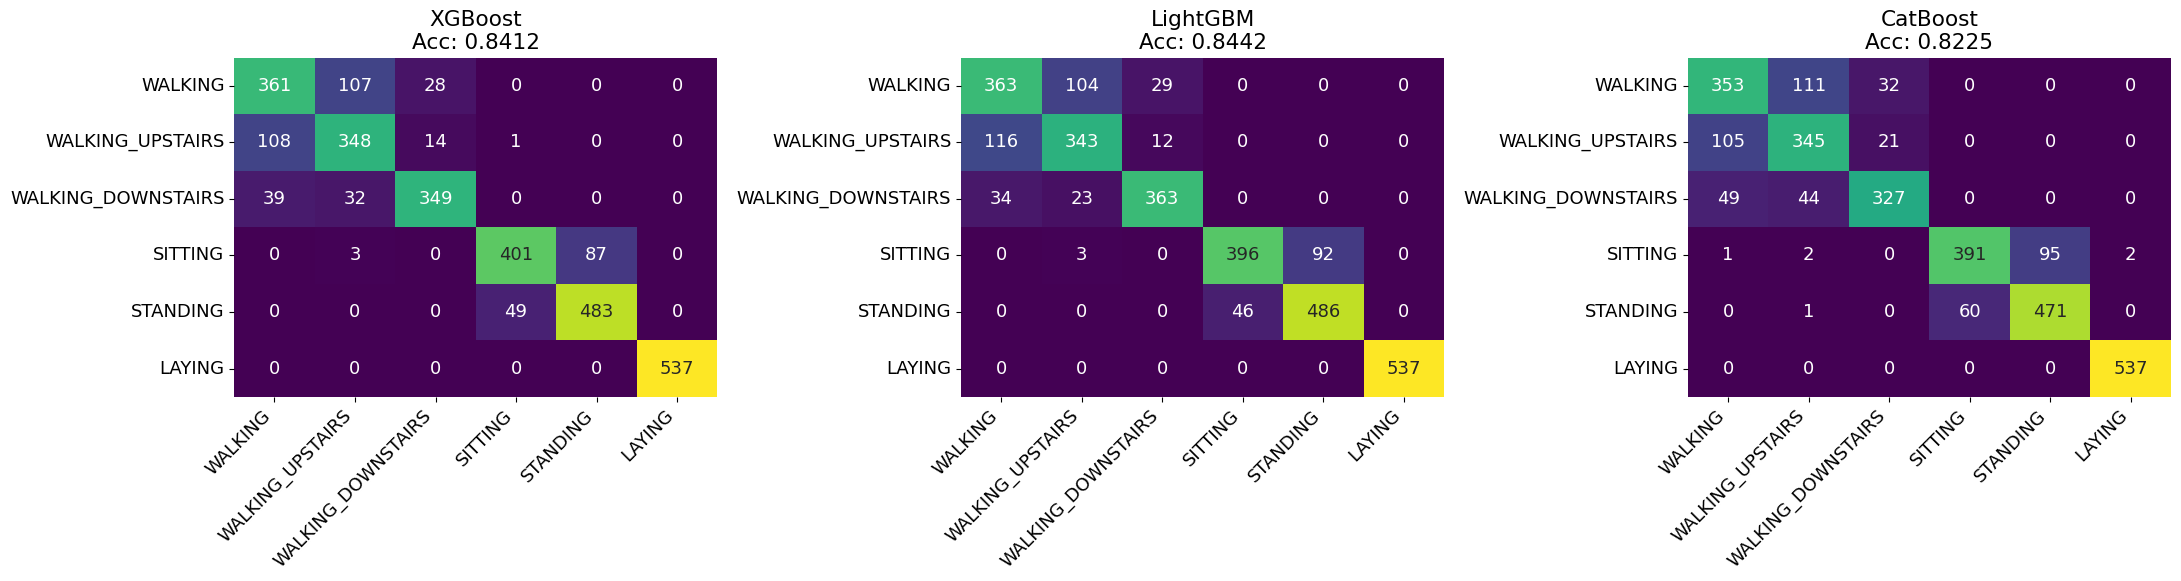

In [60]:
# Adding fixed features
def extract_enhanced_features(X_3d):
    # 1. Isolate Gravity (Total Acc - Body Acc)
    gravity = X_3d[:, :, 6:9] - X_3d[:, :, 0:3]

    # 2. Magnitudes (L2 Norm)
    mag_body = np.linalg.norm(X_3d[:, :, 0:3], axis=2, keepdims=True)
    mag_gyro = np.linalg.norm(X_3d[:, :, 3:6], axis=2, keepdims=True)
    mag_tot  = np.linalg.norm(X_3d[:, :, 6:9], axis=2, keepdims=True)

    # Combine original + magnitudes
    X_aug = np.concatenate([X_3d, mag_body, mag_gyro, mag_tot], axis=2)

    # 3. Time Domain Stats (Vectorized across all 12 channels)
    f_mean = np.mean(X_aug, axis=1)
    f_std  = np.std(X_aug, axis=1)
    f_max  = np.max(X_aug, axis=1)
    f_min  = np.min(X_aug, axis=1)

    # fft
    fft_v = np.abs(np.fft.rfft(X_aug, axis=1))
    f_energy = np.sum(fft_v**2, axis=1) / 128

    # Gravity/Tilt Features
    mean_grav = np.mean(gravity, axis=1)
    tilt = np.arccos(np.clip(mean_grav / (np.linalg.norm(mean_grav, axis=1, keepdims=True) + 1e-6), -1.0, 1.0))

    return np.hstack([f_mean, f_std, f_max, f_min, f_energy, mean_grav, tilt])

# Execution
X_train_raw, y_train, X_test_raw, y_test = load_har_dataset()
X_train = extract_enhanced_features(X_train_raw)
X_test  = extract_enhanced_features(X_test_raw)

# Weights
classes = np.unique(y_train)
weights = compute_class_weight('balanced', classes=classes, y=y_train)
w_dict = dict(zip(classes, weights))
sample_weights = np.array([w_dict[v] for v in y_train])

# --- 3. PARAMETER GRIDS FOR HALVING SEARCH ---
param_grids = {
    "XGBoost": {
        'n_estimators': [50, 150, 250],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.05, 0.1, 0.2]
    },
    "LightGBM": {
        'n_estimators': [50, 150, 250],
        'num_leaves': [31, 64],
        'learning_rate': [0.05, 0.1, 0.2]
    },
    "CatBoost": {
        'iterations': [50, 150],
        'depth': [4, 7, 10],
        'learning_rate': [0.05, 0.1]
    }
}

# Optimization loop
best_models = {}

for name in ["XGBoost", "LightGBM", "CatBoost"]:
    print(f"\n>>> Battle Royale Optimization: {name}...")

    if name == "XGBoost":
        base = XGBClassifier(tree_method='hist', n_jobs=1, random_state=42)
    elif name == "LightGBM":
        base = LGBMClassifier(n_jobs=1, class_weight='balanced', random_state=42, verbosity=-1)
    else:
        base = CatBoostClassifier(thread_count=1, auto_class_weights='Balanced', verbose=0, random_state=42)

    search = HalvingRandomSearchCV(
        base, param_grids[name], resource='n_samples',
        max_resources=len(X_train), factor=3, cv=3, n_jobs=-1, random_state=42
    )

    if name == "XGBoost":
        search.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        search.fit(X_train, y_train)

    print(f"Best Configuration: {search.best_params_}")
    best_models[name] = search.best_estimator_

# Plots and report
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, (name, model) in enumerate(best_models.items()):
    preds = model.predict(X_test).ravel()
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axes[i], cbar=False,xticklabels=activity_labels,
        yticklabels=activity_labels)
    axes[i].set_title(f"{name}\nAcc: {accuracy_score(y_test, preds):.4f}")
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
    print(f"\n{name} Report:\n", classification_report(y_test, preds))

    register_model_metrics("Enhanced Features", name, y_test, preds)

plt.tight_layout()
plt.show()



/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=204. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Score: 0.8685


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=204. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best Score: 0.8415


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=204. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Score: 0.9349


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


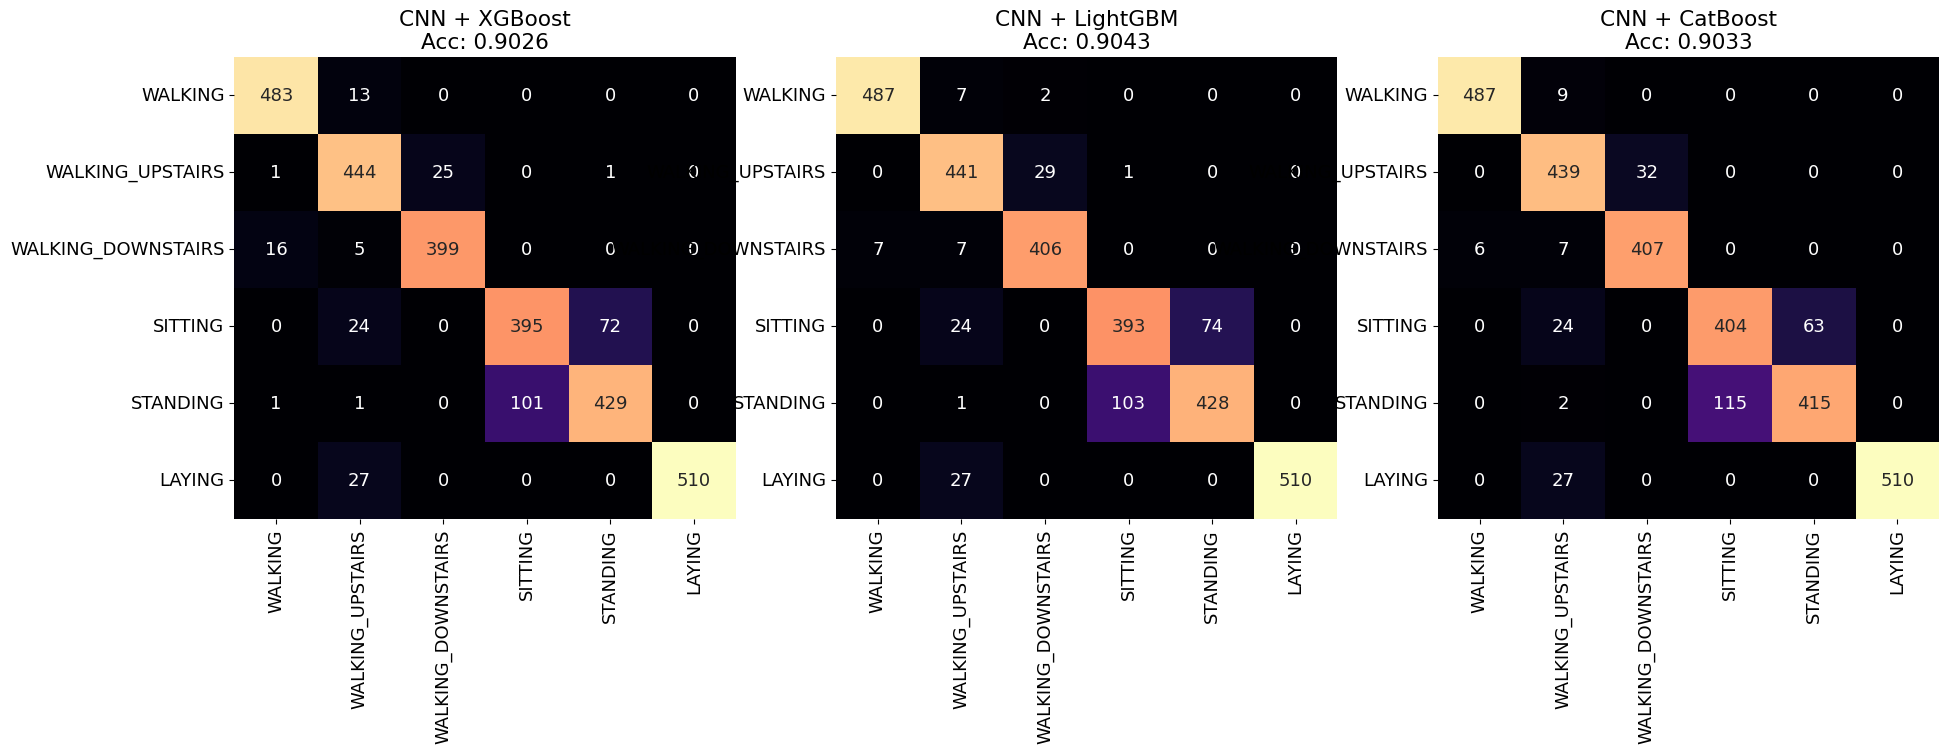

In [62]:


# Switch work on gpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_train_pt = torch.tensor(X_train_raw, dtype=torch.float32).permute(0, 2, 1)
y_train_pt = torch.tensor(y_train, dtype=torch.long)
X_test_pt = torch.tensor(X_test_raw, dtype=torch.float32).permute(0, 2, 1)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_pt, y_train_pt), batch_size=64, shuffle=True)

# CNN architecture
class HAR_CNN_Extractor(nn.Module):
    def __init__(self, num_classes=6):
        super(HAR_CNN_Extractor, self).__init__()
        self.conv1 = nn.Conv1d(9, 32, kernel_size=5, padding=2)
        self.pool = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.feature_layer = nn.Linear(64, 128)
        self.classifier = nn.Linear(128, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x, extract_features=False):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.avg_pool(x).flatten(1)
        features = self.relu(self.feature_layer(x))
        if extract_features: return features
        return self.classifier(features)

# Train cnn
model_cnn = HAR_CNN_Extractor().to(device)
optimizer = optim.Adam(model_cnn.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

model_cnn.train()
for epoch in range(15):
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model_cnn(inputs), labels)
        loss.backward()
        optimizer.step()

# Extract features from CNN
model_cnn.eval()
with torch.no_grad():
    X_train_feat = model_cnn(X_train_pt.to(device), extract_features=True).cpu().numpy()
    X_test_feat = model_cnn(X_test_pt.to(device), extract_features=True).cpu().numpy()

# Halving seatch
param_grids = {
    "XGBoost": {'n_estimators': [50, 150], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.2]},
    "LightGBM": {'n_estimators': [50, 150], 'num_leaves': [31, 64], 'learning_rate': [0.1, 0.2]},
    "CatBoost": {'iterations': [50, 150], 'depth': [4, 7], 'learning_rate': [0.1]}
}

cnn_optimized_models = {}

for name in ["XGBoost", "LightGBM", "CatBoost"]:

    if name == "XGBoost":
        base = XGBClassifier(tree_method='hist', n_jobs=1, random_state=42)
    elif name == "LightGBM":
        base = LGBMClassifier(n_jobs=1, class_weight='balanced', random_state=42, verbosity=-1)
    else:
        base = CatBoostClassifier(thread_count=1, auto_class_weights='Balanced', verbose=0, random_state=42)

    search = HalvingRandomSearchCV(
        base, param_grids[name], resource='n_samples',
        max_resources=len(X_train_feat), factor=3, cv=3, n_jobs=-1
    )

    # Use the sample_weights calculated in previous steps for XGBoost
    if name == "XGBoost":
        search.fit(X_train_feat, y_train, sample_weight=sample_weights)
    else:
        search.fit(X_train_feat, y_train)

    cnn_optimized_models[name] = search.best_estimator_
    print(f"Best Score: {search.best_score_:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(22, 6))
for i, (name, model) in enumerate(cnn_optimized_models.items()):
    preds = model.predict(X_test_feat).ravel()
    sns.heatmap(confusion_matrix(y_test, preds), annot=True, cbar=False, fmt='d', ax=axes[i], cmap='magma',xticklabels=activity_labels,
        yticklabels=activity_labels )
    axes[i].set_title(f"CNN + {name}\nAcc: {accuracy_score(y_test, preds):.4f}")


plt.show()

In [63]:
for name, model in cnn_optimized_models.items():
    preds = model.predict(X_test_feat).ravel()
    register_model_metrics("CNN Features", name, y_test, preds)
    print(f"\n================ CNN + {name} Report ================")
    print(classification_report(y_test, preds))


================ CNN + XGBoost Report ================
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       496
           1       0.86      0.94      0.90       471
           2       0.94      0.95      0.95       420
           3       0.80      0.80      0.80       491
           4       0.85      0.81      0.83       532
           5       1.00      0.95      0.97       537

    accuracy                           0.90      2947
   macro avg       0.90      0.90      0.90      2947
weighted avg       0.90      0.90      0.90      2947


================ CNN + LightGBM Report ================
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       496
           1       0.87      0.94      0.90       471
           2       0.93      0.97      0.95       420
           3       0.79      0.80      0.80       491
           4       0.85      0.80      0.83       532
           5       

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Recurrent Neural Network

In [ ]:
#LOADING DATA
def load_har_dataset():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    r = requests.get(url)
    z = zipfile.ZipFile(io.BytesIO(r.content))

    def load_group(group, base_path="UCI HAR Dataset/"):
        path = base_path + group + "/Inertial Signals/"
        filenames = [
            'body_acc_x_', 'body_acc_y_', 'body_acc_z_',
            'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_',
            'total_acc_x_', 'total_acc_y_', 'total_acc_z_'
        ]

        signals = []
        for name in filenames:
            file_path = path + name + group + ".txt"
            df = pd.read_csv(z.open(file_path), header=None, sep='\s+')
            signals.append(df.values)

        return np.transpose(np.array(signals), (1, 2, 0))

#SPLITTING DATA
    X_train_full = load_group("train")
    X_test = load_group("test")

    y_train = pd.read_csv(z.open("UCI HAR Dataset/train/y_train.txt"), header=None, sep='\s+').values
    y_test = pd.read_csv(z.open("UCI HAR Dataset/test/y_test.txt"), header=None, sep='\s+').values

    y_train_full = to_categorical(y_train - 1)
    y_test_cat = to_categorical(y_test - 1)

    return X_train_full, y_train_full, X_test, y_test_cat


X_train_full, y_train_cat_full, X_test, y_test_cat = load_har_dataset()

input_shape = (X_train_full.shape[1], X_train_full.shape[2]) # (128, 9)
num_classes = y_train_cat_full.shape[1]


<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
<>:18: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\s'
<>:28: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2629/889336330.py:18: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(z.open(file_path), header=None, sep='\s+')
/tmp/ipykernel_2629/889336330.py:27: SyntaxWarning: invalid escape sequence '\s'
  y_train = pd.read_csv(z.open("UCI HAR Dataset/train/y_train.txt"), header=None, sep='\s+').values
/tmp/ipykernel_2629/889336330.py:28: SyntaxWarning: invalid escape sequence '\s'
  y_test = pd.read_csv(z.open("UCI HAR Dataset/test/y_test.txt"), header=None, sep='\s+').values


In [ ]:
import torch

if torch.cuda.is_available():
    print(f"GPU ok: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not ok.")

GPU ok: Tesla T4


In [43]:
#IPER-PARAMETER
results = []
neurons_list = [32, 64, 128]
optimizers_list = ['adam', 'rmsprop']
batch_list = [128, 256]
epochs_max = 500
patience_value = 50

split_idx = int(len(X_train_full) * 0.8)
X_train, X_val = X_train_full[:split_idx], X_train_full[split_idx:]
y_train_cat, y_val = y_train_cat_full[:split_idx], y_train_cat_full[split_idx:]

#GRID-SEARCH
for b in batch_list:
    for n in neurons_list:
        for opt in optimizers_list:

            early_stop = EarlyStopping(
                monitor='val_loss',
                patience=patience_value,
                restore_best_weights=True
            )

            model = Sequential([
 LSTM(n, input_shape=input_shape, return_sequences=False),

Dropout(0.2),

Dense(128, activation='elu'),

Dense(num_classes, activation='softmax')
            ])

            model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

            history = model.fit(
                X_train, y_train_cat,
                epochs=epochs_max,
                batch_size=b,
                validation_data=(X_val, y_val),
                callbacks=[early_stop],
                verbose=2
            )

            best_epoch_idx = np.argmin(history.history['val_loss'])
            best_val_loss = history.history['val_loss'][best_epoch_idx]
            best_val_acc = history.history['val_accuracy'][best_epoch_idx]
            stopped_epoch = len(history.history['loss'])

            results.append({
                'neurons': n,
                'optimizer': opt,
                'batch_size': b,
                'val_acc': best_val_acc,
                'val_loss': best_val_loss,
                'stopped_at': stopped_epoch
            })

            print(f"Neurons: {n} | Batch: {b} | Opt: {opt} | "
                  f"Val Loss: {best_val_loss:.4f} | Val Acc: {best_val_acc:.4f} | Stopped at: {stopped_epoch}")

results = sorted(results, key=lambda x: x['val_loss'])
print("\nBest Configuration Found:")
print(results[0])

Epoch 1/500


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


46/46 - 3s - 57ms/step - accuracy: 0.4020 - loss: 1.4558 - val_accuracy: 0.5133 - val_loss: 1.2037
Epoch 2/500
46/46 - 1s - 12ms/step - accuracy: 0.5400 - loss: 1.0357 - val_accuracy: 0.6506 - val_loss: 1.0649
Epoch 3/500
46/46 - 1s - 12ms/step - accuracy: 0.6562 - loss: 0.8062 - val_accuracy: 0.6574 - val_loss: 0.8479
Epoch 4/500
46/46 - 1s - 20ms/step - accuracy: 0.6885 - loss: 0.6733 - val_accuracy: 0.7267 - val_loss: 0.8075
Epoch 5/500
46/46 - 1s - 28ms/step - accuracy: 0.7162 - loss: 0.6086 - val_accuracy: 0.7152 - val_loss: 0.8144
Epoch 6/500
46/46 - 3s - 67ms/step - accuracy: 0.7385 - loss: 0.5896 - val_accuracy: 0.7478 - val_loss: 0.7605
Epoch 7/500
46/46 - 1s - 28ms/step - accuracy: 0.7776 - loss: 0.5260 - val_accuracy: 0.7967 - val_loss: 0.7115
Epoch 8/500
46/46 - 2s - 48ms/step - accuracy: 0.8101 - loss: 0.4728 - val_accuracy: 0.8049 - val_loss: 0.7087
Epoch 9/500
46/46 - 1s - 13ms/step - accuracy: 0.8264 - loss: 0.4320 - val_accuracy: 0.8260 - val_loss: 0.6808
Epoch 10/500


In [73]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, MaxPooling1D, LSTM, Dense

best_res = min(results, key=lambda x: x['val_loss'])
print(f"\nBest configuration: {best_res['neurons']} neurons with {best_res['optimizer']}, batch : {best_res['batch_size']}, validation accuracy: {best_res['val_acc']}, validation loss: {best_res['val_loss']} ")


best_model = Sequential([
                    LSTM(best_res['neurons'], input_shape=input_shape),
                    Dropout(0.2),
                    Dense(128, activation='elu'),
                    Dense(num_classes, activation='softmax')
                ])

best_model.compile(
    optimizer=best_res['optimizer'],
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


best_model.fit(
    X_train, y_train_cat,
    epochs=(best_res['stopped_at']-patience_value),
    batch_size=best_res['batch_size'],
    verbose=2
)

test_loss, test_acc = best_model.evaluate(X_test, y_test_cat, verbose=0)


print("-" * 30)
print(f"FINAL RESULT OVERTEST SET:")
print(f"Test Loss: {test_loss:.4f}")
print("-" * 30)


Best configuration: 128 neurons with adam, batch : 128, validation accuracy: 0.9027872085571289, validation loss: 0.22393624484539032 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Data cardinality is ambiguous. Make sure all arrays contain the same number of samples.'x' sizes: 7352
'y' sizes: 5881


In [72]:
#PREDICTION
y_pred = best_model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)

activity_labels = [
    'WALKING',
    'WALKING UPSTAIRS',
    'WALKING DOWNSTAIRS',
    'SITTING',
    'STANDING',
    'LAYING'
]

#CONFUSION MATRIX
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis',
            xticklabels=activity_labels,
            yticklabels=activity_labels)
plt.title('Confusion Matrix - Human Activity Recognition')
plt.ylabel('True Activity')
plt.xlabel('Predicte Activity')
plt.show()

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [71]:

y_pred = best_model.predict(X_test)
y_pred_bool = np.argmax(y_pred, axis=1)
y_true_bool = np.argmax(y_test_cat, axis=1)
register_model_metrics("Single Model", "RNN", y_true_bool, y_pred_bool)
print(classification_report(y_true_bool, y_pred_bool, target_names=activity_labels))

ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

/tmp/ipykernel_2629/2781232724.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', len(labels))


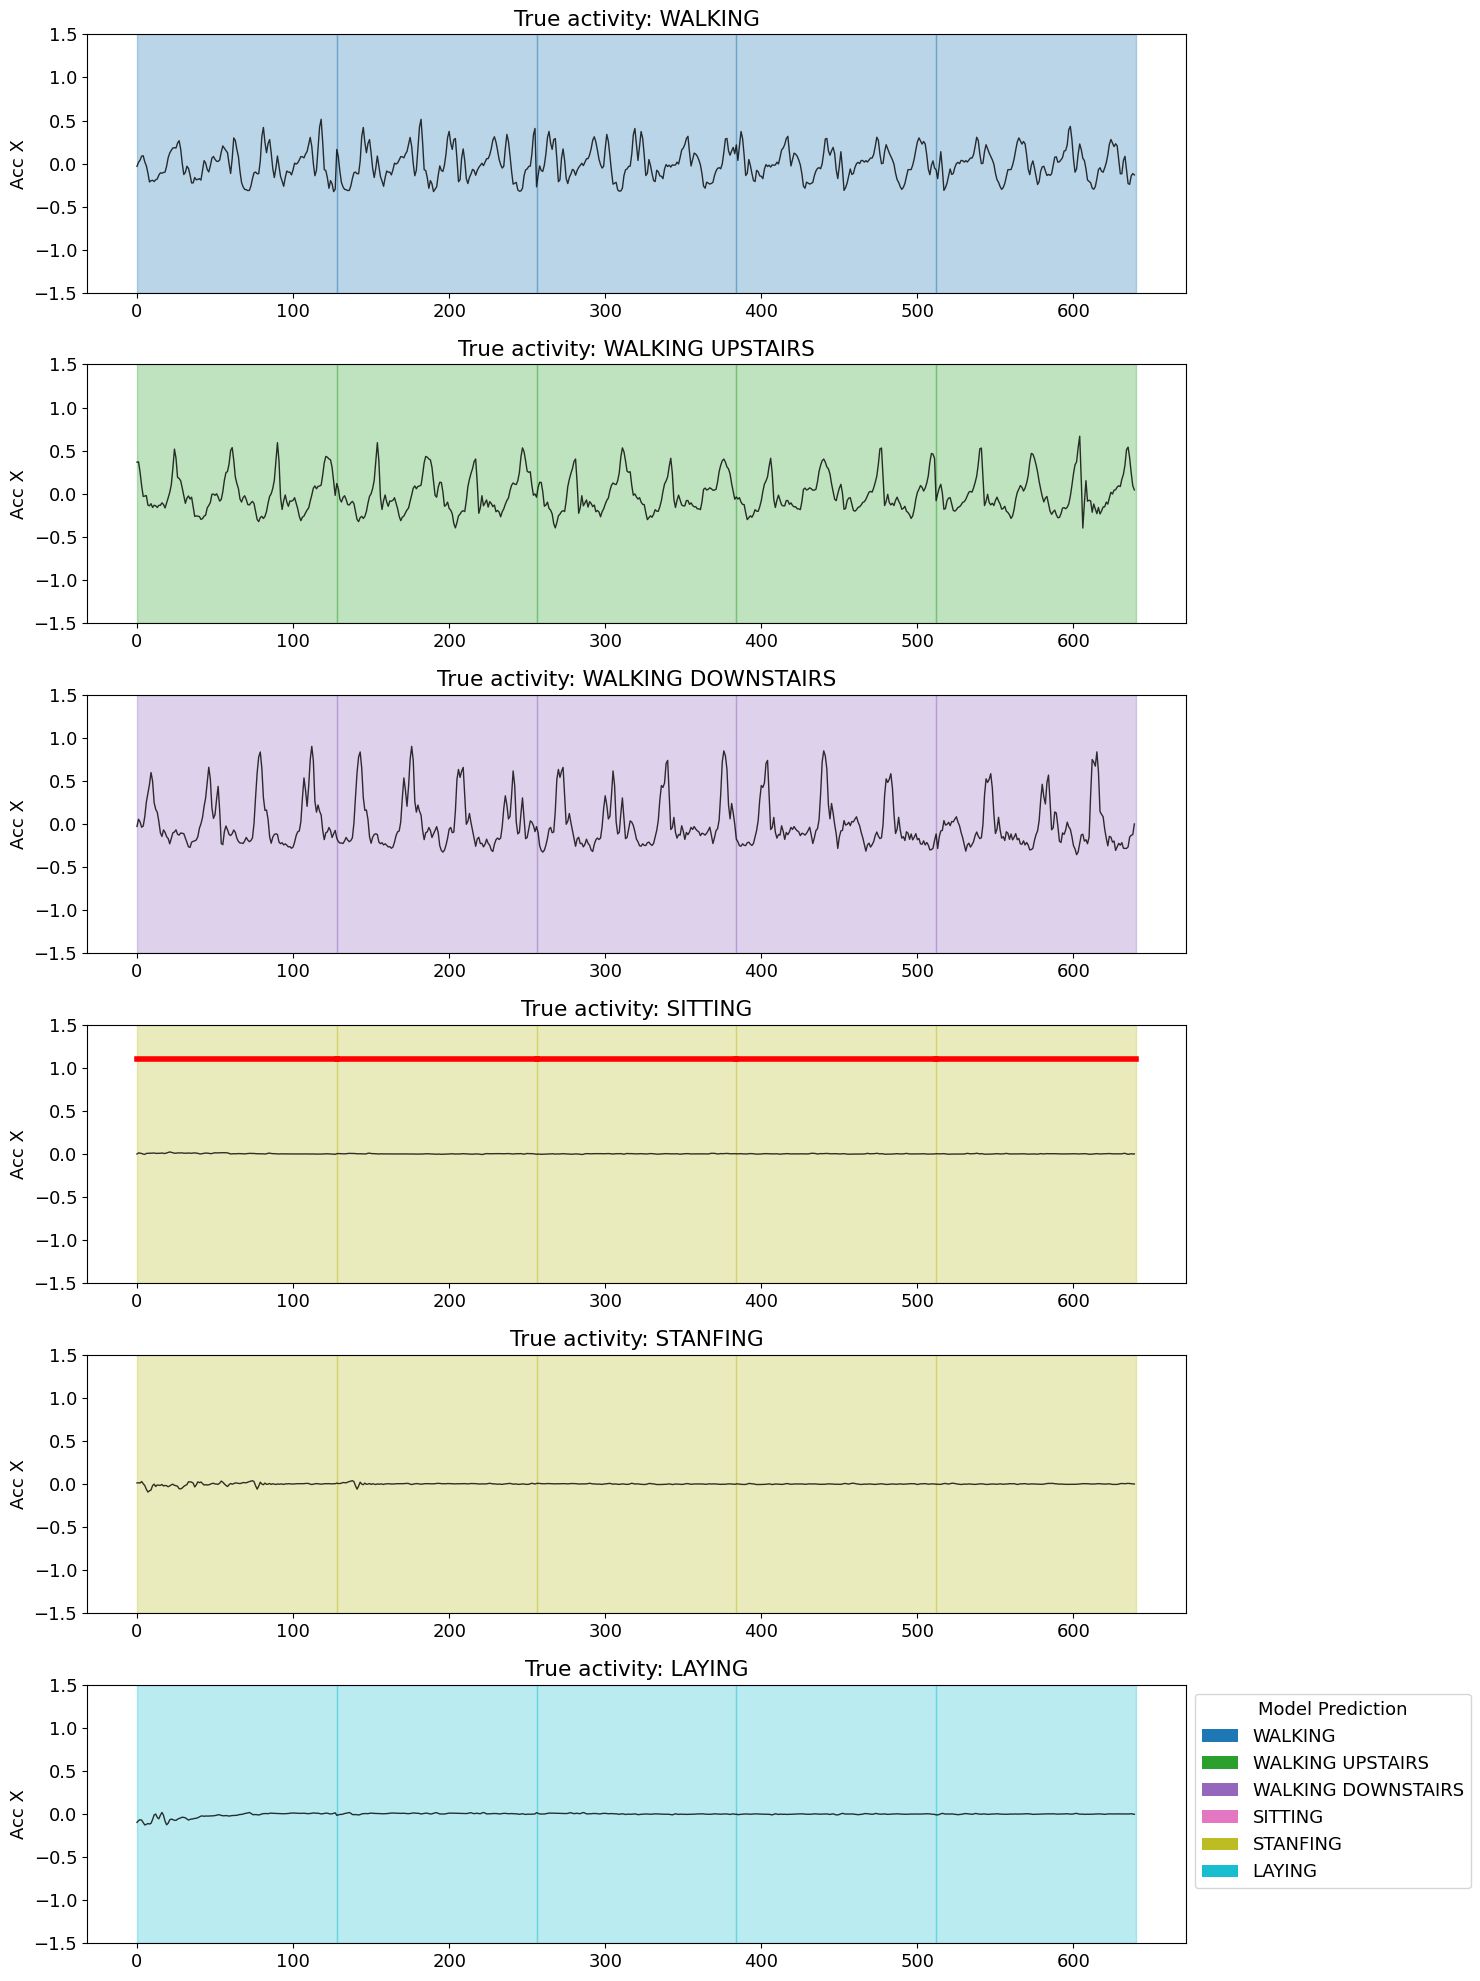

In [52]:

#PLOT PREDICTIONS

def plot_all_activities_comparison(X, y_true, y_pred, labels):
    fig, axes = plt.subplots(6, 1, figsize=(15, 20))
    colors = plt.cm.get_cmap('tab10', len(labels))

    # Creazione manuale dei rettangoli per la legenda
    recs = [mpatches.Rectangle((0, 0), 1, 1, fc=colors(i)) for i in range(len(labels))]

    for i, label in enumerate(labels):
        idx_list = np.where(np.argmax(y_true, axis=1) == i)[0]

        if len(idx_list) > 0:
            start_idx = idx_list[0]
            num_windows = 5
            selected_range = range(start_idx, start_idx + num_windows)

            signal = X[selected_range, :, 0].reshape(-1)
            axes[i].plot(signal, color='black', linewidth=1, alpha=0.8)

            for j, window_idx in enumerate(selected_range):
                p_class = np.argmax(y_pred[window_idx])
                t_class = np.argmax(y_true[window_idx])

                start_x, end_x = j * 128, (j + 1) * 128

                axes[i].axvspan(start_x, end_x, color=colors(p_class), alpha=0.3)

                if p_class != t_class:
                    axes[i].plot([start_x, end_x], [1.1, 1.1], color='red', linewidth=4)

            axes[i].set_title(f"True activity: {label}")
            axes[i].set_ylim(-1.5, 1.5)
            axes[i].set_ylabel("Acc X")


    plt.legend(recs, labels, loc='upper left', bbox_to_anchor=(1, 1), title="Model Prediction")
    plt.tight_layout()
    plt.show()

plot_all_activities_comparison(X_test, y_test_cat, y_pred, activity_labels)

In [64]:

def plot_sitting_vs_standing_samples(X, y_true, y_pred, labels, num_samples=10):
    try:
        sitting_idx = list(labels).index("Sitting")
        standing_idx = list(labels).index("Standing")
    except ValueError:
        print("Label not found.")
        return

    target_classes = [sitting_idx, standing_idx]
    colors = plt.cm.get_cmap('tab10', len(labels))

    plt.figure(figsize=(15, 10))

    for i, class_id in enumerate(target_classes):
        indices = np.where(np.argmax(y_true, axis=1) == class_id)[0]

        num_to_draw = min(num_samples, len(indices))
        random_selection = np.random.choice(indices, num_to_draw, replace=False)

        plt.subplot(2, 1, i + 1)


        signal_to_plot = X[random_selection, :, 0].reshape(-1)
        plt.plot(signal_to_plot, color='black', linewidth=0.8, alpha=0.7)

        for j, idx in enumerate(random_selection):
            p_class = np.argmax(y_pred[idx])
            t_class = np.argmax(y_true[idx])

            start_x, end_x = j * 128, (j + 1) * 128

            plt.axvspan(start_x, end_x, color=colors(p_class), alpha=0.3)

            if p_class != t_class:
                plt.plot([start_x, end_x], [1.1, 1.1], color='red', linewidth=4)

        plt.title(f"True samples: {labels[class_id]}")
        plt.ylabel("Signal (Acc X)")
        plt.ylim(-1.3, 1.3)
        plt.grid(axis='x', linestyle='--', alpha=0.3)

    recs = [mpatches.Rectangle((0,0),1,1, fc=colors(c), alpha=0.3) for c in range(len(labels))]
    plt.legend(recs, labels, loc='center left', bbox_to_anchor=(1, 1.1), title="Model Prediction")

    plt.tight_layout()
    plt.show()

plot_sitting_vs_standing_samples(X_test, y_test_cat, y_pred, activity_labels)

Etichette non trovate. Verifica il contenuto di activity_labels.



TOTAL PERFORMANCE COMPARISON TABLE
          Pipeline     Model Accuracy  Macro_Precision  Macro_Recall  Macro_F1
Final Single Model BestModel   0.9199         0.922872      0.921270  0.920427
          Raw Data   XGBoost   0.9087         0.909604      0.907684  0.907437
          Raw Data  LightGBM   0.9070         0.905912      0.907464  0.906383
      CNN Features  LightGBM   0.9043         0.904675      0.906578  0.905130
      CNN Features  CatBoost   0.9033         0.904288      0.905928  0.904212
      CNN Features   XGBoost   0.9026         0.903313      0.904510  0.903389
          Raw Data  CatBoost   0.8928         0.891437      0.892351  0.891637
 Enhanced Features  LightGBM   0.8442         0.844672      0.840738  0.841973
 Enhanced Features   XGBoost   0.8412         0.841653      0.837037  0.838667
 Enhanced Features  CatBoost   0.8225         0.822783      0.817404  0.819220


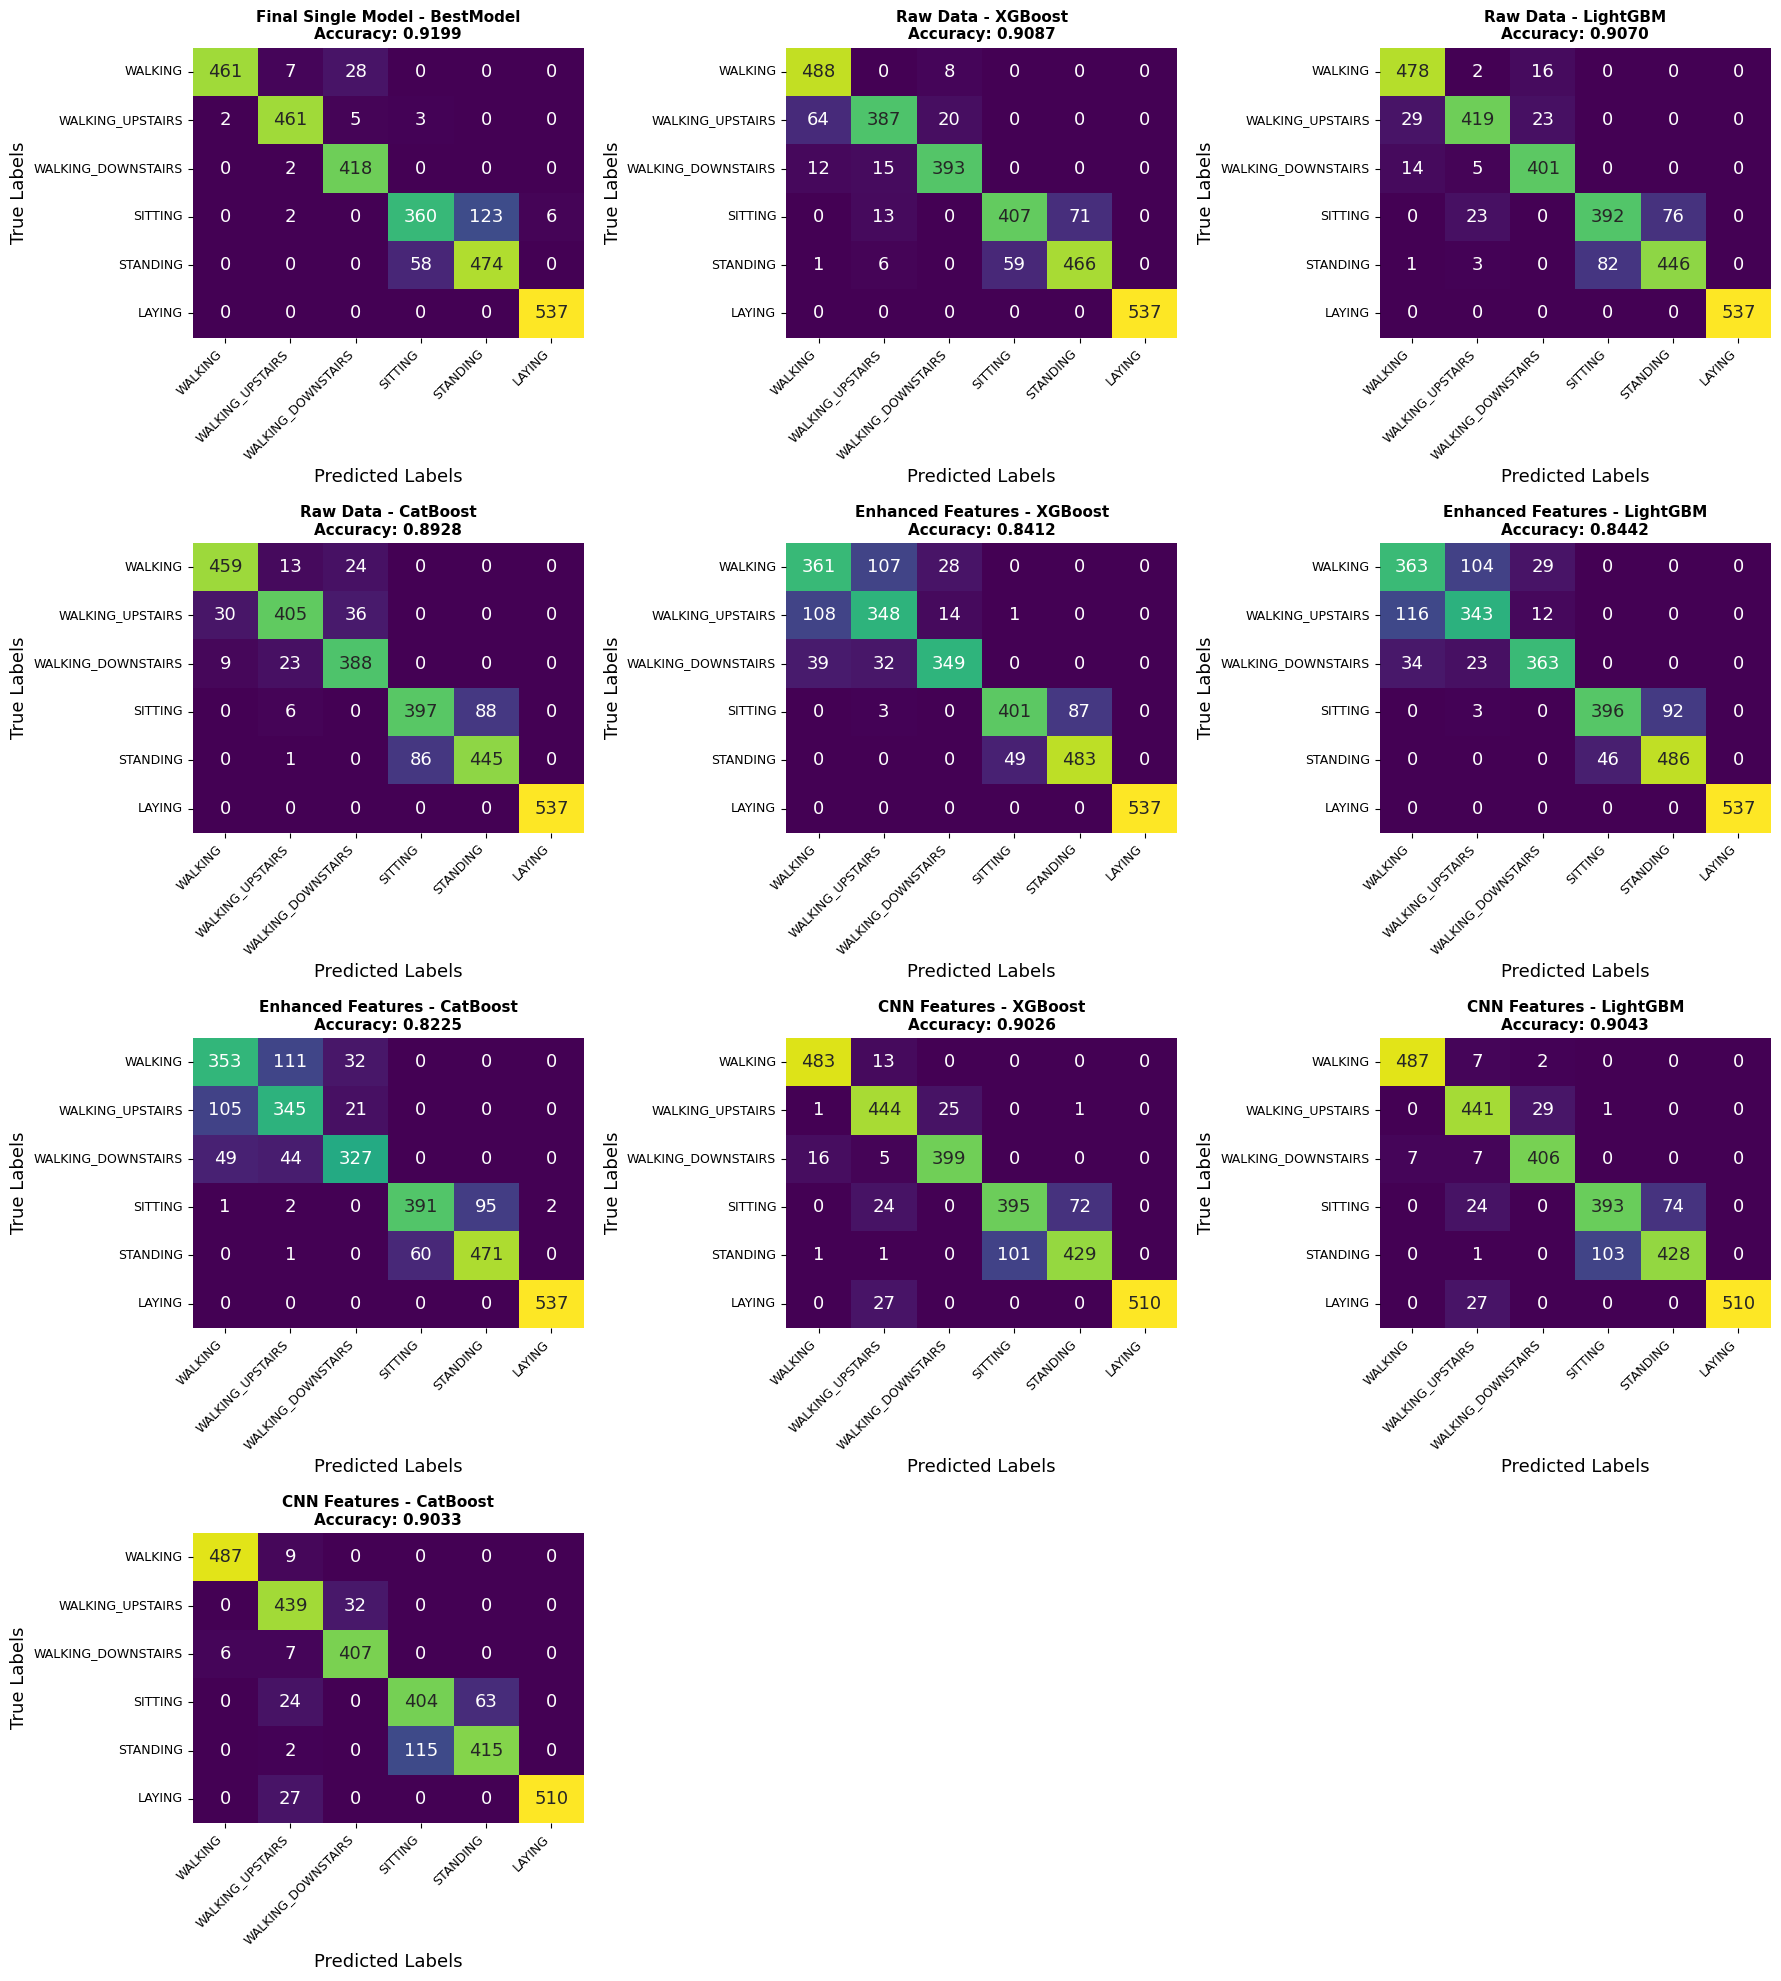

In [65]:
performance_dataframe = pd.DataFrame(performance_registry)
performance_dataframe = performance_dataframe.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("TOTAL PERFORMANCE COMPARISON TABLE")
print("="*80)
print(performance_dataframe.to_string(index=False, formatters={"Accuracy": "{:.4f}".format}))
print("="*80)

total_plots = len(confusion_matrices_registry)
grid_cols = 3
grid_rows = (total_plots + grid_cols - 1) // grid_cols

fig, axes = plt.subplots(grid_rows, grid_cols, figsize=(6 * grid_cols, 5 * grid_rows))
axes = axes.flatten()

for index, (title, (matrix, score)) in enumerate(confusion_matrices_registry.items()):
    sns.heatmap(matrix, annot=True, fmt="d", cmap="viridis", ax=axes[index], cbar=False,
                xticklabels=activity_labels, yticklabels=activity_labels)
    axes[index].set_title(f"{title}\nAccuracy: {score:.4f}", fontsize=11, weight="bold")
    axes[index].set_xticklabels(axes[index].get_xticklabels(), rotation=45, ha="right", fontsize=9)
    axes[index].set_yticklabels(axes[index].get_yticklabels(), fontsize=9)
    axes[index].set_ylabel("True Labels")
    axes[index].set_xlabel("Predicted Labels")

for empty_index in range(index + 1, len(axes)):
    fig.delaxes(axes[empty_index])

plt.tight_layout()
plt.show()

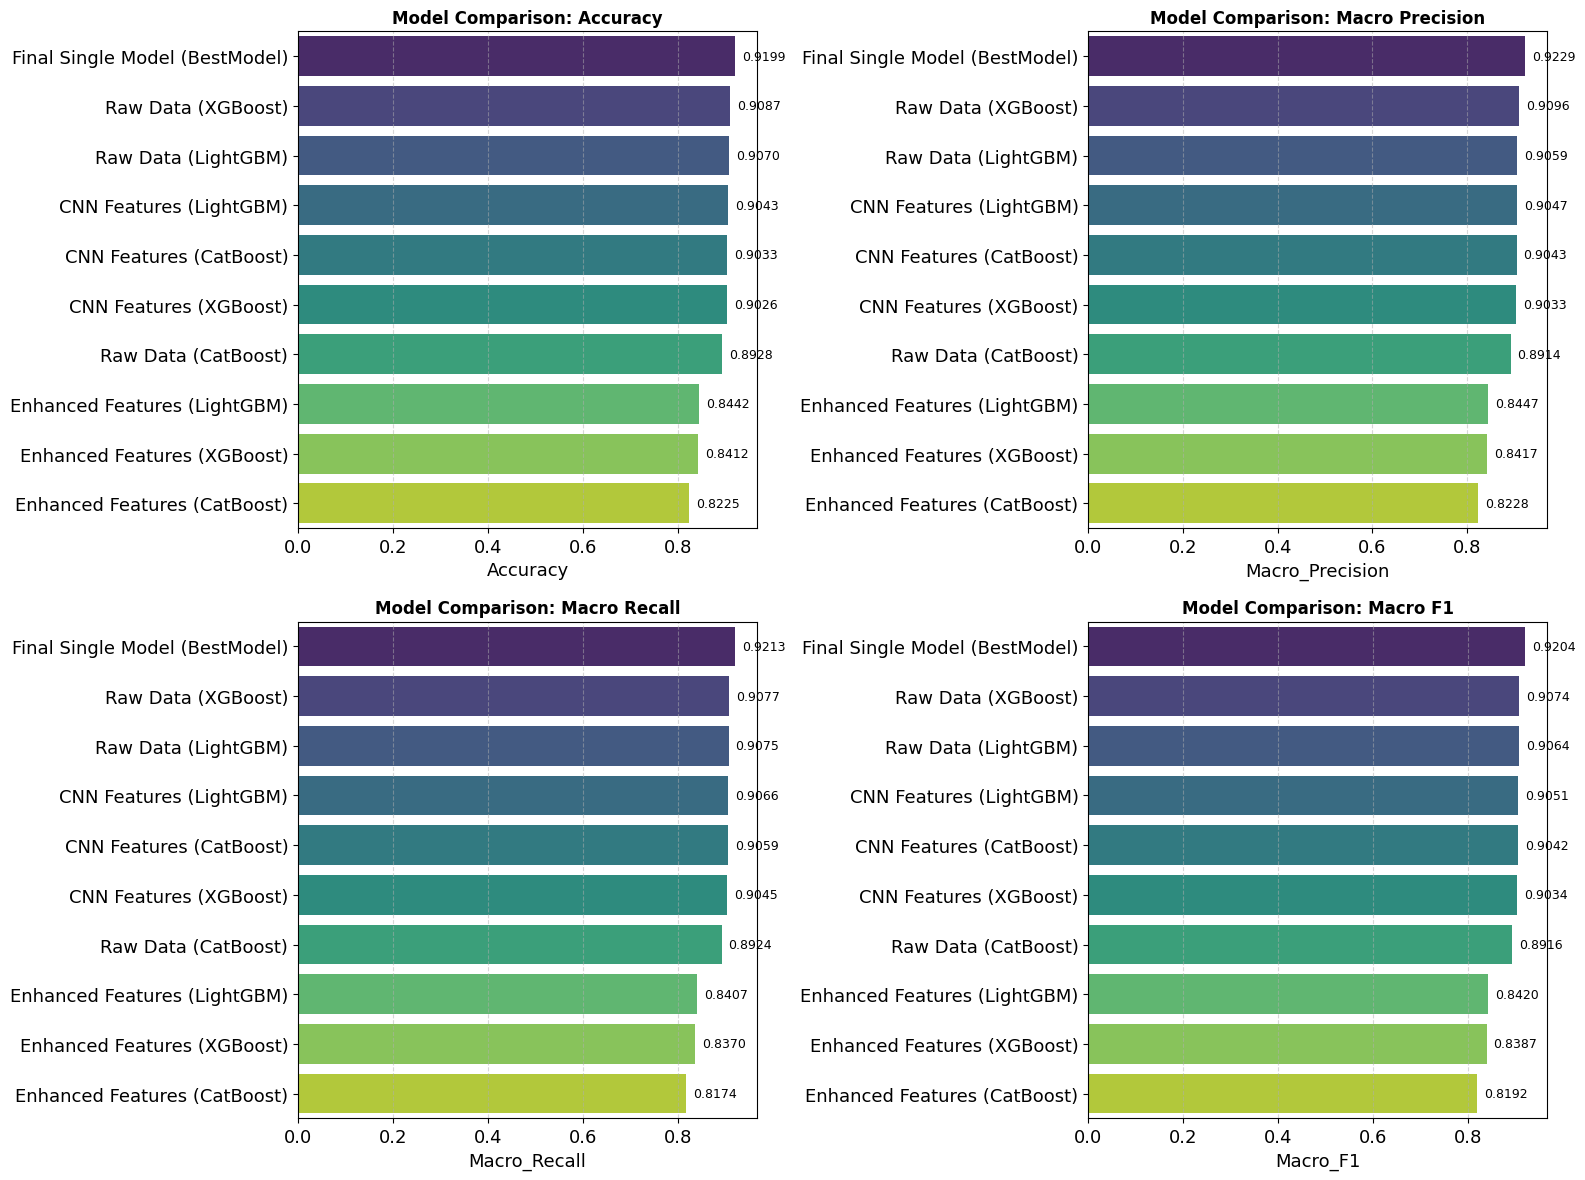

In [74]:
metrics_list = ["Accuracy", "Macro_Precision", "Macro_Recall", "Macro_F1"]
performance_dataframe["Full_Model_Name"] = performance_dataframe["Pipeline"] + " (" + performance_dataframe["Model"] + ")"

chart_fig, chart_axes = plt.subplots(2, 2, figsize=(16, 12))
chart_axes = chart_axes.flatten()

for idx, metric in enumerate(metrics_list):
    sorted_df = performance_dataframe.sort_values(by=metric, ascending=False)

    sns.barplot(
        x=metric,
        y="Full_Model_Name",
        data=sorted_df,
        ax=chart_axes[idx],
        palette="viridis",
        hue="Full_Model_Name",
        legend=False
    )

    chart_axes[idx].set_title(f"Model Comparison: {metric.replace('_', ' ')}", fontsize=12, weight="bold")
    chart_axes[idx].set_xlabel(metric)
    chart_axes[idx].set_ylabel("")
    chart_axes[idx].grid(axis="x", linestyle="--", alpha=0.5)

    for container in chart_axes[idx].containers:
        chart_axes[idx].bar_label(container, fmt="%.4f", padding=5, fontsize=9)

plt.tight_layout()
plt.show()